# Model Experiment — `LightGBM`





## Setup

In [1]:
import pathlib
if pathlib.Path('/kaggle/input').exists():
    !pip install -q lightgbm wandb python-dotenv mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 94.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 71.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.8/958.8 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 11.9 MB/s eta 0:00:00


## 0. Config & environment

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

KAGGLE_INPUT = Path('/kaggle/input')
KAGGLE_COMPETITION = 'walmart-recruiting-store-sales-forecasting'
ON_KAGGLE = KAGGLE_INPUT.exists()

if ON_KAGGLE:
    WORKING_DIR = Path('/kaggle/working')
else:
    PROJECT_ROOT = Path.cwd().parent
    WORKING_DIR = PROJECT_ROOT
    load_dotenv(PROJECT_ROOT / '.env')

def _find_file(stem):

    names = (f'{stem}.csv', f'{stem}.csv.zip')
    if ON_KAGGLE:
        search_roots = [
            KAGGLE_INPUT / KAGGLE_COMPETITION,
            KAGGLE_INPUT / 'competitions' / KAGGLE_COMPETITION,
        ]
        for root in search_roots:
            if root.exists():
                for name in names:
                    p = root / name
                    if p.exists():
                        return p
        for name in names:
            matches = list(KAGGLE_INPUT.rglob(name))
            if matches:
                return matches[0]
        raise FileNotFoundError(
            f"Could not find {stem}.csv[.zip] anywhere under {KAGGLE_INPUT}. "
            f"Contents of {KAGGLE_INPUT}: {list(KAGGLE_INPUT.iterdir())}"
        )
    else:
        p = PROJECT_ROOT / 'data' / 'raw' / f'{stem}.csv'
        if not p.exists():
            raise FileNotFoundError(f'{p} not found')
        return p

TRAIN_CSV = _find_file('train')
TEST_CSV = _find_file('test')
FEATURES_CSV = _find_file('features')
STORES_CSV = _find_file('stores')

RANDOM_SEED = 42
TARGET = 'Weekly_Sales'
HOLIDAY_WEIGHT = 5
NON_HOLIDAY_WEIGHT = 1

if ON_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        client = UserSecretsClient()
        for key in ('MLFLOW_TRACKING_URI', 'MLFLOW_TRACKING_USERNAME', 'MLFLOW_TRACKING_PASSWORD', 'WANDB_API_KEY'):
            try:
                os.environ.setdefault(key, client.get_secret(key))
            except Exception:
                pass
    except Exception:
        pass

MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')
MLFLOW_TRACKING_USERNAME = os.getenv('MLFLOW_TRACKING_USERNAME')
MLFLOW_TRACKING_PASSWORD = os.getenv('MLFLOW_TRACKING_PASSWORD')

print('On Kaggle:', ON_KAGGLE)
print('train:', TRAIN_CSV)
print('test:', TEST_CSV)
print('features:', FEATURES_CSV)
print('stores:', STORES_CSV)

On Kaggle: True
train: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
test: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip
features: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
stores: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv


## 1. Data loading helpers

In [3]:
import pandas as pd

def _read_bool(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.strip().str.upper().map({'TRUE': True, 'FALSE': False})

def load_stores():
    return pd.read_csv(STORES_CSV)

def load_features():
    df = pd.read_csv(FEATURES_CSV, parse_dates=['Date'])
    df['IsHoliday'] = _read_bool(df['IsHoliday'])
    df = df.sort_values(['Store', 'Date'])
    for col in ('CPI', 'Unemployment'):
        df[col] = df.groupby('Store')[col].transform(lambda s: s.ffill().bfill())
    return df.reset_index(drop=True)

def load_raw(split):
    path = TRAIN_CSV if split == 'train' else TEST_CSV
    df = pd.read_csv(path, parse_dates=['Date'])
    df['IsHoliday'] = _read_bool(df['IsHoliday'])
    return df

def load_merged(split='train'):
    base = load_raw(split)
    stores = load_stores()
    feats = load_features().drop(columns=['IsHoliday'])
    df = base.merge(stores, on='Store', how='left')
    df = df.merge(feats, on=['Store', 'Date'], how='left')
    df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
    return df

## 2. Metric (WMAE) & cross-validation helpers

In [4]:
def weights_from_holiday(is_holiday):
    is_holiday = np.asarray(is_holiday).astype(bool)
    return np.where(is_holiday, HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT).astype(float)

def wmae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = weights_from_holiday(is_holiday)
    return float(np.sum(w * np.abs(y_true - y_pred)) / np.sum(w))

In [5]:
def _sorted_unique_dates(dates):
    return np.sort(pd.to_datetime(dates).unique())

def time_holdout(df, weeks=8, date_col='Date'):
    uniq = _sorted_unique_dates(df[date_col])
    if weeks >= len(uniq):
        raise ValueError(f'weeks={weeks} >= number of distinct weeks {len(uniq)}')
    cutoff = uniq[-weeks]
    d = pd.to_datetime(df[date_col]).to_numpy()
    train_idx = np.where(d < cutoff)[0]
    val_idx = np.where(d >= cutoff)[0]
    return train_idx, val_idx

def expanding_splits(df, n_splits=3, horizon=8, date_col='Date'):
    uniq = _sorted_unique_dates(df[date_col])
    needed = horizon * n_splits
    if needed >= len(uniq):
        raise ValueError(f'Need > {needed} distinct weeks for {n_splits} folds of {horizon}; have {len(uniq)}.')
    d = pd.to_datetime(df[date_col]).to_numpy()
    for k in range(n_splits):
        end_offset = needed - k * horizon
        start_offset = end_offset - horizon
        val_start = uniq[-end_offset]
        val_end = uniq[-start_offset] if start_offset > 0 else None
        train_idx = np.where(d < val_start)[0]
        if val_end is None:
            val_idx = np.where(d >= val_start)[0]
        else:
            val_idx = np.where((d >= val_start) & (d < val_end))[0]
        yield train_idx, val_idx

## 3. Feature engineering helpers

In [6]:
MARKDOWN_COLS = [f'MarkDown{i}' for i in range(1, 6)]

def add_calendar_features(df):
    df = df.copy()
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
    df['DayOfYear'] = df['Date'].dt.dayofyear
    df['Quarter'] = df['Date'].dt.quarter
    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    df['Week_sin'] = np.sin(2 * np.pi * df['Week'] / 52)
    df['Week_cos'] = np.cos(2 * np.pi * df['Week'] / 52)
    return df

def merge_static(df, stores_df, features_df):

    df = df.merge(stores_df, on='Store', how='left')
    feats = features_df.drop(columns=['IsHoliday'])
    df = df.merge(feats, on=['Store', 'Date'], how='left')
    for c in MARKDOWN_COLS:
        df[c] = df[c].fillna(0.0)
    for c in ('Temperature', 'Fuel_Price', 'CPI', 'Unemployment'):
        df[c] = df[c].fillna(df[c].median())
    return df

def target_encode_fit(X, y):

    y = pd.Series(np.asarray(y, dtype=float), index=X.index)
    store_mean = y.groupby(X['Store']).mean()
    dept_mean = y.groupby(X['Dept']).mean()
    storedept_mean = y.groupby([X['Store'], X['Dept']]).mean()
    global_mean = float(y.mean())
    return {'store': store_mean, 'dept': dept_mean, 'storedept': storedept_mean, 'global': global_mean}

def target_encode_transform(df, encodings):

    df = df.copy()
    df['Store_Mean_Sales'] = df['Store'].map(encodings['store']).fillna(encodings['global'])
    df['Dept_Mean_Sales'] = df['Dept'].map(encodings['dept']).fillna(encodings['global'])
    key = pd.Series(list(zip(df['Store'], df['Dept'])), index=df.index)
    df['StoreDept_Mean_Sales'] = key.map(encodings['storedept']).fillna(df['Dept_Mean_Sales'])
    return df

CANDIDATE_CAT_COLS = ['Store', 'Dept', 'Type']
CANDIDATE_NUM_COLS = [
    'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Year', 'Month', 'Week', 'DayOfYear', 'Quarter',
    'Month_sin', 'Month_cos', 'Week_sin', 'Week_cos', 'IsHoliday',
] + MARKDOWN_COLS
CANDIDATE_ENC_COLS = ['Store_Mean_Sales', 'Dept_Mean_Sales', 'StoreDept_Mean_Sales']
CANDIDATE_FEATURE_COLS = CANDIDATE_CAT_COLS + CANDIDATE_NUM_COLS + CANDIDATE_ENC_COLS

## 4. Weights & Biases setup

In [7]:
import wandb
import numpy as np, pandas as pd

MODEL_NAME = 'LightGBM'
WANDB_PROJECT = 'walmart-sales-forecasting'
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sgurj22 (TwoMusketeers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 5. MLflow tracking setup


In [8]:
import mlflow

def init_tracking(experiment=None):
    uri = MLFLOW_TRACKING_URI
    if uri:
        if 'dagshub.com' in uri and not uri.rstrip('/').endswith('.mlflow'):
            uri = uri.rstrip('/') + '.mlflow'
            print(f'NOTE: appended .mlflow to MLFLOW_TRACKING_URI (DagsHub requires it) -> {uri}')
        mlflow.set_tracking_uri(uri)
        if MLFLOW_TRACKING_USERNAME:
            os.environ['MLFLOW_TRACKING_USERNAME'] = MLFLOW_TRACKING_USERNAME
        if MLFLOW_TRACKING_PASSWORD:
            os.environ['MLFLOW_TRACKING_PASSWORD'] = MLFLOW_TRACKING_PASSWORD
    else:
        print('WARNING: MLFLOW_TRACKING_URI not set -- check Add-ons > Secrets is attached to THIS notebook.')
        print('Falling back to a LOCAL sqlite store: this will NOT persist beyond this session and your team will not see it.')
        mlflow.set_tracking_uri(f"sqlite:///{WORKING_DIR / 'mlflow.db'}")
    if experiment:
        mlflow.set_experiment(experiment)
    return mlflow.get_tracking_uri()

EXPERIMENT = f'{MODEL_NAME}_Training'
mlflow_uri = init_tracking(EXPERIMENT)
print('MLflow ->', mlflow_uri, '| experiment:', EXPERIMENT)

Falling back to a LOCAL sqlite store: this will NOT persist beyond this session and your team will not see it.


2026/07/17 14:04:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/17 14:04:52 INFO mlflow.store.db.utils: Updating database tables
2026/07/17 14:04:54 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM_Training' does not exist. Creating a new experiment.


MLflow -> sqlite:////kaggle/working/mlflow.db | experiment: LightGBM_Training


## Load raw data

In [9]:
raw_train = load_raw('train')
raw_test  = load_raw('test')
STORES_DF = load_stores()
FEATURES_DF = load_features()
raw_train.shape, raw_test.shape

((421570, 5), (115064, 4))

## Run 1 — Cleaning


In [10]:
n_series = raw_train.groupby(['Store', 'Dept']).ngroups
n_negative_sales = int((raw_train['Weekly_Sales'] < 0).sum())
markdown_missing = {c: float(FEATURES_DF[c].isna().mean()) for c in MARKDOWN_COLS}
econ_missing = {c: float(FEATURES_DF[c].isna().mean()) for c in ('Temperature', 'Fuel_Price', 'CPI', 'Unemployment')}

cleaning_stats = {
    'n_train_rows': len(raw_train),
    'n_series': n_series,
    'n_negative_sales': n_negative_sales,
    **{f'pct_missing_{k}': v for k, v in markdown_missing.items()},
    **{f'pct_missing_{k}': v for k, v in econ_missing.items()},
}

with mlflow.start_run(run_name=f'{MODEL_NAME}_Cleaning'):
    for k, v in cleaning_stats.items():
        mlflow.log_metric(k, v)

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='cleaning', name=f'{MODEL_NAME}_Cleaning')
wandb.log(cleaning_stats)
run.finish()
print(n_series, 'series |', n_negative_sales, 'negative Weekly_Sales rows')
print('MarkDown missing fractions:', markdown_missing)

n_negative_sales,▁
n_series,▁
n_train_rows,▁
pct_missing_CPI,▁
pct_missing_Fuel_Price,▁
pct_missing_MarkDown1,▁
pct_missing_MarkDown2,▁
pct_missing_MarkDown3,▁
pct_missing_MarkDown4,▁
pct_missing_MarkDown5,▁
+2,...


3331 series | 1285 negative Weekly_Sales rows
MarkDown missing fractions: {'MarkDown1': 0.5076923076923077, 'MarkDown2': 0.6433455433455434, 'MarkDown3': 0.5588522588522589, 'MarkDown4': 0.577045177045177, 'MarkDown5': 0.5054945054945055}


## Run 2 — Feature Selection


In [11]:
fs_tr_idx, fs_va_idx = time_holdout(raw_train, weeks=39)
fs_tr = raw_train.iloc[fs_tr_idx]

fs_feat = merge_static(add_calendar_features(fs_tr), STORES_DF, FEATURES_DF)
fs_enc = target_encode_fit(fs_tr, fs_tr['Weekly_Sales'])
fs_feat = target_encode_transform(fs_feat, fs_enc)
for c in CANDIDATE_CAT_COLS:
    fs_feat[c] = fs_feat[c].astype('category')

import lightgbm as lgb

quick_model = lgb.LGBMRegressor(objective='mae', n_estimators=150, random_state=RANDOM_SEED, verbosity=-1)
quick_model.fit(
    fs_feat[CANDIDATE_FEATURE_COLS], fs_tr['Weekly_Sales'],
    sample_weight=weights_from_holiday(fs_tr['IsHoliday']),
    categorical_feature=CANDIDATE_CAT_COLS,
)
importances = pd.Series(quick_model.feature_importances_, index=CANDIDATE_FEATURE_COLS).sort_values(ascending=False)

FINAL_FEATURE_COLS = importances[importances > 0].index.tolist()
FINAL_CAT_COLS = [c for c in CANDIDATE_CAT_COLS if c in FINAL_FEATURE_COLS]
dropped = [c for c in CANDIDATE_FEATURE_COLS if c not in FINAL_FEATURE_COLS]

feature_selection_params = {
    'n_candidate_features': len(CANDIDATE_FEATURE_COLS),
    'n_final_features': len(FINAL_FEATURE_COLS),
    'dropped_zero_importance': dropped,
    'lag_of_sales_features_used': 'none (leakage-avoidance design choice, see Theory)',
}

with mlflow.start_run(run_name=f'{MODEL_NAME}_Feature_Selection'):
    for k, v in feature_selection_params.items():
        mlflow.log_param(k, v)
    for feat, imp in importances.items():
        mlflow.log_metric(f'importance_{feat}', float(imp))

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='feature_selection', name=f'{MODEL_NAME}_Feature_Selection')
wandb.config.update(feature_selection_params)
wandb.log({'feature_importance_table': wandb.Table(dataframe=importances.rename('importance').reset_index().rename(columns={'index': 'feature'}))})
run.finish()

print('dropped (zero importance):', dropped)
print('final feature count:', len(FINAL_FEATURE_COLS))
importances

dropped (zero importance): ['Type', 'Quarter']
final feature count: 24


Dept                    1657
Store                    846
StoreDept_Mean_Sales     640
Week                     319
DayOfYear                159
Week_cos                 135
Week_sin                 118
Fuel_Price               107
Month                    105
Temperature              100
Month_cos                 56
CPI                       45
Month_sin                 40
IsHoliday                 37
MarkDown3                 34
Dept_Mean_Sales           26
Unemployment              23
Year                      15
MarkDown5                 11
MarkDown4                 11
Size                       9
MarkDown1                  3
MarkDown2                  3
Store_Mean_Sales           1
Type                       0
Quarter                    0
dtype: int32

## 6. Pipeline wrapper

In [12]:
from sklearn.base import BaseEstimator, RegressorMixin

class LightGBMPipeline(BaseEstimator, RegressorMixin):

    def __init__(self, num_leaves=31, learning_rate=0.05, n_estimators=300,
                 max_depth=-1, min_child_samples=20, random_state=42):
        self.num_leaves = num_leaves
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_child_samples = min_child_samples
        self.random_state = random_state

    def _build_features(self, X, encodings):
        df = merge_static(add_calendar_features(X), STORES_DF, FEATURES_DF)
        df = target_encode_transform(df, encodings)
        for c in FINAL_CAT_COLS:
            df[c] = df[c].astype('category')
        return df[FINAL_FEATURE_COLS]

    def fit(self, X, y=None):
        y = np.asarray(y, dtype=float)
        self.encodings_ = target_encode_fit(X, y)
        Xf = self._build_features(X, self.encodings_)
        w = weights_from_holiday(X['IsHoliday'])
        self.model_ = lgb.LGBMRegressor(
            objective='mae', num_leaves=self.num_leaves, learning_rate=self.learning_rate,
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            min_child_samples=self.min_child_samples, random_state=self.random_state,
            verbosity=-1,
        )
        self.model_.fit(Xf, y, sample_weight=w, categorical_feature=FINAL_CAT_COLS)
        self.feature_names_ = FINAL_FEATURE_COLS
        return self

    def predict(self, X):
        Xf = self._build_features(X, self.encodings_)
        preds = self.model_.predict(Xf)
        return np.clip(preds, 0, None)

## Run 3 — Cross-validation (curated hyperparameter search)


In [13]:
import itertools

candidate_num_leaves = [63, 127, 255, 511]
candidate_learning_rates = [0.1, 0.15, 0.2]
candidate_n_estimators = [500, 800, 1200]

configs = [
    {'num_leaves': nl, 'learning_rate': lr, 'n_estimators': ne}
    for nl, lr, ne in itertools.product(candidate_num_leaves, candidate_learning_rates, candidate_n_estimators)
]
print(len(configs), 'configs to try')

hp_idx, _ = time_holdout(raw_train, weeks=39)
raw_train_hp = raw_train.iloc[hp_idx].reset_index(drop=True)

trial_results = []
with mlflow.start_run(run_name=f'{MODEL_NAME}_CV'):
    mlflow.log_param('n_configs', len(configs))
    mlflow.log_param('n_folds', 3)
    mlflow.log_param('final_feature_count', len(FINAL_FEATURE_COLS))
    for i, cfg in enumerate(configs):
        run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='cv', name=f'{MODEL_NAME}_CV_trial{i}', config=cfg, reinit=True)
        fold_scores = []
        for k, (tr_idx, va_idx) in enumerate(expanding_splits(raw_train_hp, n_splits=3, horizon=8)):
            tr, va = raw_train_hp.iloc[tr_idx], raw_train_hp.iloc[va_idx]
            pipe = LightGBMPipeline(**cfg, random_state=RANDOM_SEED)
            pipe.fit(tr, tr['Weekly_Sales'])
            pred = pipe.predict(va)
            score = wmae(va['Weekly_Sales'], pred, va['IsHoliday'])
            fold_scores.append(score)
            wandb.log({'fold': k, 'fold_wmae': score})
        cv_mean = float(np.mean(fold_scores))
        wandb.log({'cv_wmae_mean': cv_mean, 'cv_wmae_std': float(np.std(fold_scores))})
        run.finish()
        trial_results.append({'config': cfg, 'cv_wmae_mean': cv_mean})
        cfg_tag = f"nl{cfg['num_leaves']}_lr{cfg['learning_rate']}_ne{cfg['n_estimators']}"
        mlflow.log_metric(f'wmae_{cfg_tag}', cv_mean)
        print(f'config {i} {cfg}: CV WMAE={cv_mean:,.1f}')

    best_trial = min(trial_results, key=lambda t: t['cv_wmae_mean'])
    best_config = best_trial['config']
    mlflow.log_param('best_config', best_config)
    mlflow.log_metric('best_cv_wmae', best_trial['cv_wmae_mean'])

print('best config:', best_config, '| CV WMAE:', best_trial['cv_wmae_mean'])

36 configs to try


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


cv_wmae_mean,▁
cv_wmae_std,▁
fold,▁▅█
fold_wmae,▁█▅
cv_wmae_mean,2474.87451
cv_wmae_std,582.98897
fold,2
fold_wmae,2483.94096


config 0 {'num_leaves': 63, 'learning_rate': 0.1, 'n_estimators': 500}: CV WMAE=2,474.9


cv_wmae_mean,▁
cv_wmae_std,▁
fold,▁▅█
fold_wmae,▁█▆
cv_wmae_mean,2282.74382
cv_wmae_std,388.38806
fold,2
fold_wmae,2436.21897


...

config 33 {'num_leaves': 511, 'learning_rate': 0.2, 'n_estimators': 500}: CV WMAE=2,335.4


cv_wmae_mean,▁
cv_wmae_std,▁
fold,▁▅█
fold_wmae,▁█▅
cv_wmae_mean,2325.25858
cv_wmae_std,465.28054
fold,2
fold_wmae,2378.48087


config 34 {'num_leaves': 511, 'learning_rate': 0.2, 'n_estimators': 800}: CV WMAE=2,325.3


cv_wmae_mean,▁
cv_wmae_std,▁
fold,▁▅█
fold_wmae,▁█▅
cv_wmae_mean,2309.85473
cv_wmae_std,451.48462
fold,2
fold_wmae,2379.27896


config 35 {'num_leaves': 511, 'learning_rate': 0.2, 'n_estimators': 1200}: CV WMAE=2,309.9
best config: {'num_leaves': 511, 'learning_rate': 0.1, 'n_estimators': 1200} | CV WMAE: 2258.1406335492034


## Run 3 results — visual comparison



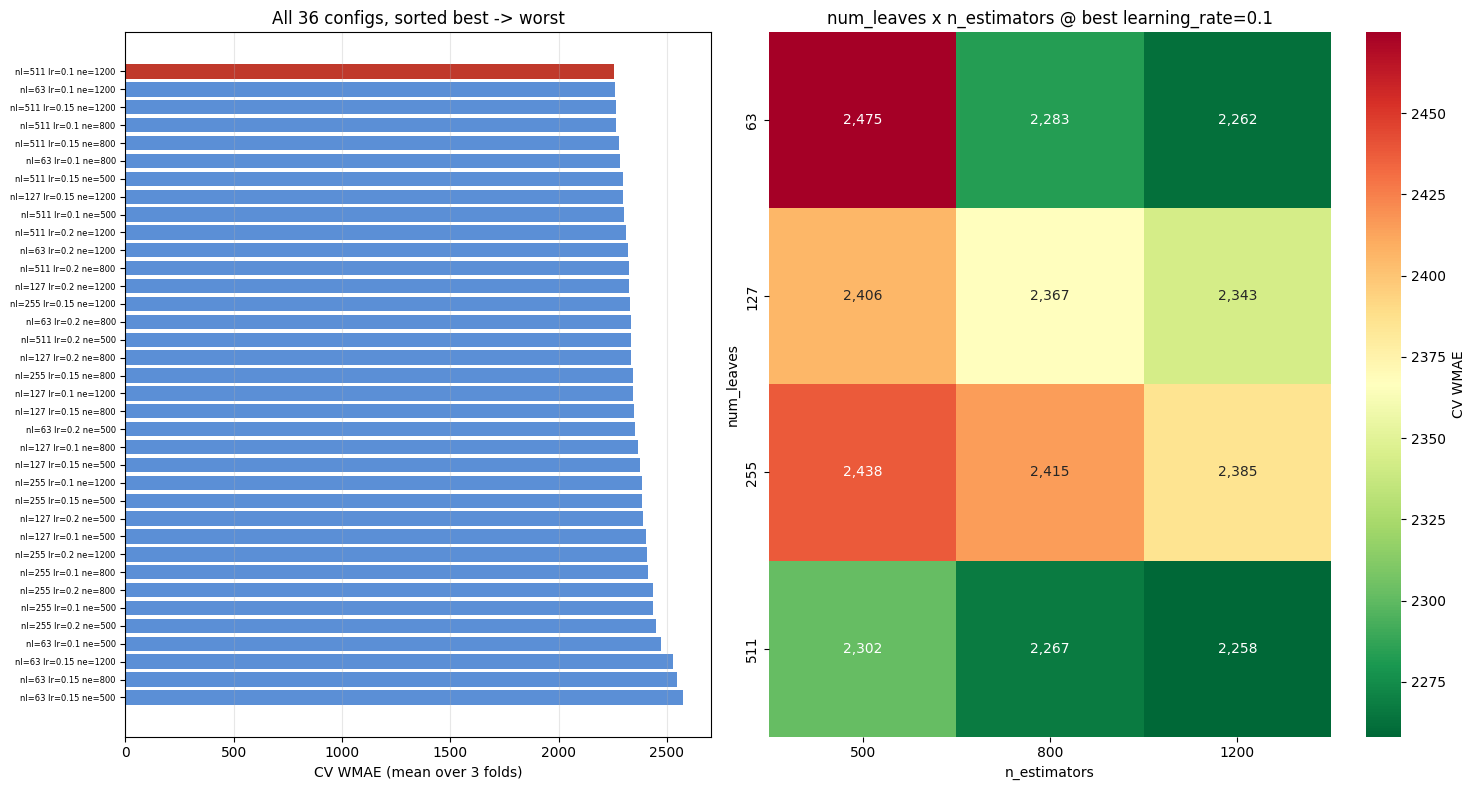

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

cv_df = pd.DataFrame([
    {**t['config'], 'cv_wmae_mean': t['cv_wmae_mean']}
    for t in trial_results
]).sort_values('cv_wmae_mean').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={'width_ratios': [1, 1.2]})

labels = [f"nl={r.num_leaves} lr={r.learning_rate:g} ne={r.n_estimators}" for r in cv_df.itertuples()]
bar_colors = ['#c0392b' if i == 0 else '#5b8fd6' for i in range(len(cv_df))]
axes[0].barh(range(len(cv_df)), cv_df['cv_wmae_mean'], color=bar_colors)
axes[0].set_yticks(range(len(cv_df)))
axes[0].set_yticklabels(labels, fontsize=6)
axes[0].invert_yaxis()
axes[0].set_xlabel('CV WMAE (mean over 3 folds)')
axes[0].set_title(f'All {len(cv_df)} configs, sorted best -> worst')
axes[0].grid(axis='x', alpha=0.3)

best_lr = cv_df.iloc[0]['learning_rate']
pivot = cv_df[cv_df['learning_rate'] == best_lr].pivot(index='num_leaves', columns='n_estimators', values='cv_wmae_mean')
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='RdYlGn_r', ax=axes[1], cbar_kws={'label': 'CV WMAE'})
axes[1].set_title(f'num_leaves x n_estimators @ best learning_rate={best_lr:g}')

plt.tight_layout()

cv_csv_path = pathlib.Path(WORKING_DIR) / 'lightgbm_cv_results.csv'
cv_df.to_csv(cv_csv_path, index=False)

with mlflow.start_run(run_name=f'{MODEL_NAME}_CV_Summary'):
    mlflow.log_figure(fig, 'cv_comparison.png')
    mlflow.log_artifact(str(cv_csv_path))

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='cv_summary', name=f'{MODEL_NAME}_CV_Summary')
wandb.log({'cv_comparison': wandb.Image(fig), 'cv_results_table': wandb.Table(dataframe=cv_df)})
run.finish()

plt.show()

## Run 4 — Final fit + save Pipeline


In [15]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='final', name=f'{MODEL_NAME}_Final', config=best_config)

with mlflow.start_run(run_name=f'{MODEL_NAME}_Final') as mlflow_run:
    mlflow.log_params(best_config)

    holdout_tr, holdout_va = time_holdout(raw_train, weeks=39)
    p = LightGBMPipeline(**best_config, random_state=RANDOM_SEED)
    p.fit(raw_train.iloc[holdout_tr], raw_train.iloc[holdout_tr]['Weekly_Sales'])
    hv = raw_train.iloc[holdout_va]
    holdout_pred = p.predict(hv)
    holdout_wmae = wmae(hv['Weekly_Sales'], holdout_pred, hv['IsHoliday'])
    wandb.log({'val_WMAE': holdout_wmae})
    mlflow.log_metric('val_WMAE', holdout_wmae)
    print('39w-holdout WMAE (val_WMAE):', holdout_wmae)

    final_pipe = LightGBMPipeline(**best_config, random_state=RANDOM_SEED)
    final_pipe.fit(raw_train, raw_train['Weekly_Sales'])

    import pickle, pathlib
    from sklearn.pipeline import Pipeline as SkPipeline
    from mlflow.models import infer_signature

    out_dir = pathlib.Path(WORKING_DIR) / 'models' / MODEL_NAME
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / 'pipeline.pkl', 'wb') as f:
        pickle.dump(final_pipe, f)
    wandb.log_artifact(str(out_dir), name=f'{MODEL_NAME}_pipeline', type='model')

    sk_pipe = SkPipeline([('model', final_pipe)])
    example = raw_test.head(5)
    sig = infer_signature(example, final_pipe.predict(example))
    mlflow.sklearn.log_model(sk_pipe, artifact_path='pipeline', signature=sig, input_example=example, serialization_format='cloudpickle')
    mlflow.log_param('test_horizon', int(raw_test['Date'].nunique()))

run.finish()
print('saved pipeline to', out_dir, '| MLflow run:', mlflow_run.info.run_id)

39w-holdout WMAE (val_WMAE): 1758.4669407486379


wandb: Adding directory to artifact (/kaggle/working/models/LightGBM)... Done. 0.2s
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/17 16:18:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/17 16:18:07 WARNING mlflow.sklearn: Saving scikit

val_WMAE,▁
val_WMAE,1758.46694


saved pipeline to /kaggle/working/models/LightGBM | MLflow run: ad64760a3a4447e0a44fab38f90a2b4f


## Run 4 results — holdout diagnostics


holdout_wmae,▁
holdout_wmae_holiday,▁
holdout_wmae_non_holiday,▁
holdout_wmae,1758.46694
holdout_wmae_holiday,1816.03515
holdout_wmae_non_holiday,1742.79889


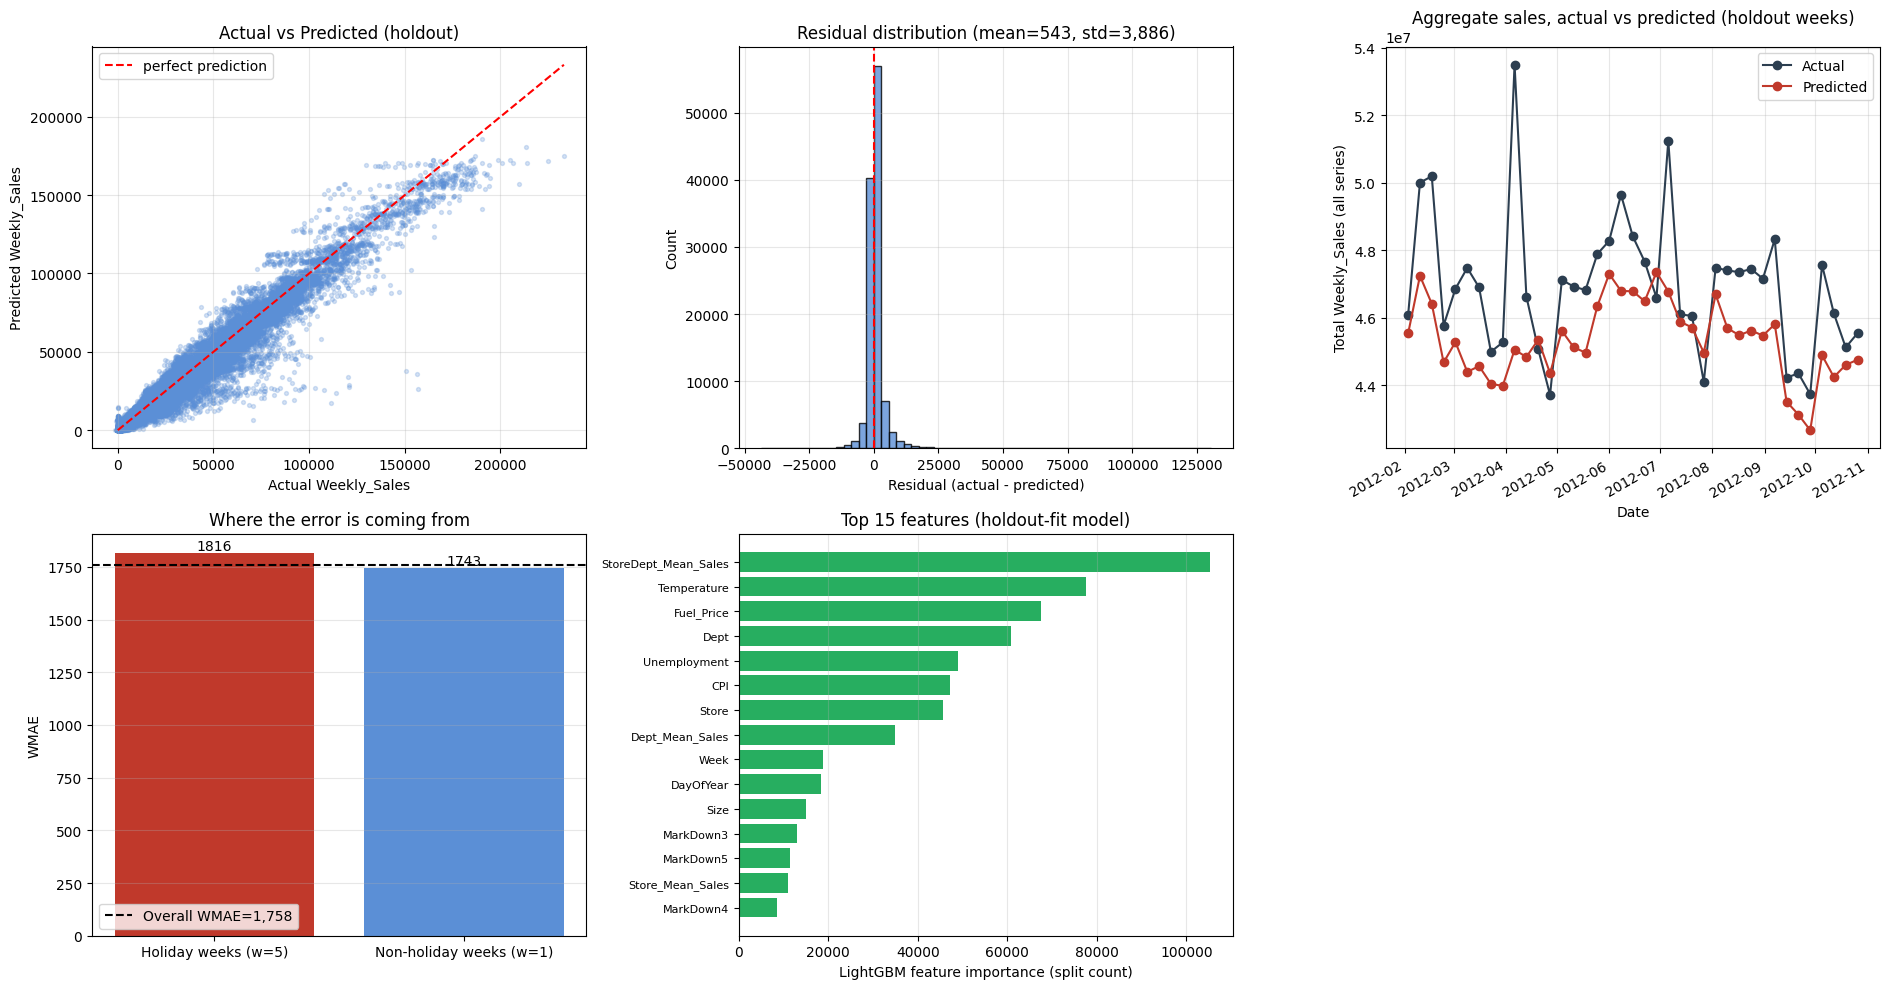

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

ax = axes[0, 0]
ax.scatter(hv['Weekly_Sales'], holdout_pred, s=8, alpha=0.25, color='#5b8fd6')
lims = [0, max(hv['Weekly_Sales'].max(), holdout_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='perfect prediction')
ax.set_xlabel('Actual Weekly_Sales')
ax.set_ylabel('Predicted Weekly_Sales')
ax.set_title('Actual vs Predicted (holdout)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
residuals = hv['Weekly_Sales'].to_numpy() - holdout_pred
ax.hist(residuals, bins=60, color='#5b8fd6', edgecolor='black', alpha=0.8)
ax.axvline(0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Residual (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residual distribution (mean={residuals.mean():,.0f}, std={residuals.std():,.0f})')
ax.grid(alpha=0.3)

ax = axes[0, 2]
agg = hv.assign(pred=holdout_pred).groupby('Date')[['Weekly_Sales', 'pred']].sum()
ax.plot(agg.index, agg['Weekly_Sales'], marker='o', label='Actual', color='#2c3e50')
ax.plot(agg.index, agg['pred'], marker='o', label='Predicted', color='#c0392b')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly_Sales (all series)')
ax.set_title('Aggregate sales, actual vs predicted (holdout weeks)')
ax.legend()
ax.grid(alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax = axes[1, 0]
holiday_mask = hv['IsHoliday'].to_numpy().astype(bool)
wmae_holiday = wmae(hv['Weekly_Sales'][holiday_mask], holdout_pred[holiday_mask], hv['IsHoliday'][holiday_mask]) if holiday_mask.any() else float('nan')
wmae_non_holiday = wmae(hv['Weekly_Sales'][~holiday_mask], holdout_pred[~holiday_mask], hv['IsHoliday'][~holiday_mask])
bars = ax.bar(['Holiday weeks (w=5)', 'Non-holiday weeks (w=1)'], [wmae_holiday, wmae_non_holiday], color=['#c0392b', '#5b8fd6'])
ax.bar_label(bars, fmt='%.0f')
ax.axhline(holdout_wmae, color='black', linestyle='--', lw=1.5, label=f'Overall WMAE={holdout_wmae:,.0f}')
ax.set_ylabel('WMAE')
ax.set_title('Where the error is coming from')
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
fi = pd.Series(p.model_.feature_importances_, index=p.feature_names_).sort_values(ascending=False).head(15)
ax.barh(range(len(fi)), fi.values[::-1], color='#27ae60')
ax.set_yticks(range(len(fi)))
ax.set_yticklabels(fi.index[::-1], fontsize=8)
ax.set_xlabel('LightGBM feature importance (split count)')
ax.set_title('Top 15 features (holdout-fit model)')
ax.grid(axis='x', alpha=0.3)

axes[1, 2].axis('off')

plt.tight_layout()

diag_run = mlflow.start_run(run_name=f'{MODEL_NAME}_Final_Diagnostics')
mlflow.log_figure(fig, 'holdout_diagnostics.png')
mlflow.log_metric('holdout_wmae_holiday', wmae_holiday)
mlflow.log_metric('holdout_wmae_non_holiday', wmae_non_holiday)
mlflow.end_run()

wandb_diag_run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='final_diagnostics', name=f'{MODEL_NAME}_Final_Diagnostics')
wandb.log({'holdout_diagnostics': wandb.Image(fig), 'holdout_wmae': holdout_wmae, 'holdout_wmae_holiday': wmae_holiday, 'holdout_wmae_non_holiday': wmae_non_holiday})
wandb_diag_run.finish()

plt.show()